# EDA

| Feature  | Açıklama                         | Veri Tipi | Kategorik Anlam |
| -------- | -------------------------------- | --------- | ----- |
| age      | Yaş                              | Numeric   | - |
| sex      | Cinsiyet (1 = erkek, 0 = kadın)  | Categorical | 0: kadın, 1: erkek |
| cp       | Göğüs ağrısı tipi (0–3)          | Categorical | 0: Tip 1 / 1: Tip 2 / 2: Tip 3 / 3: Tip 4 |
| trestbps | Dinlenme tansiyonu               | Numeric   | - |
| chol     | Kolesterol                       | Numeric   | - |
| fbs      | Açlık kan şekeri > 120           | Categorical | 0: < 120 / 1: >= 120 |
| restecg  | EKG sonucu                       | Categorical | 0: Normal / 1: Düzensiz / 2: Defektif |
| thalach  | Maksimum kalp atış hızı          | Numeric   | - |
| exang    | Egzersize bağlı anjina           | Categorical | 0: Yok / 1: Var |
| oldpeak  | ST depresyonu                    | Numeric (float) | - |
| slope    | ST eğimi                         | Categorical | 0: Tip 1 / 1: Tip 2 / 2: Tip 3 |
| ca       | Major damar sayısı               | Categorical | 0: Yok / 1: 1 / 2: 2 / 3: 3 |
| thal     | Thalassemia                      | Categorical | 0: Normal / 1: Düzensiz / 2: Defektif |
| target   | **Kalp hastalığı var mı? (1/0)** | Categorical | 0: Yok / 1: Var |


### Bölüm 1: Kurulum ve Profesyonel Ayarlar

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Profesyonel Görünüm Ayarları
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)
# Renk Paleti: Hedef değişken (0/1) için net zıtlık sağlayan renkler (Örn: Mavi vs Kırmızı)
custom_palette = ["#3498db", "#e74c3c"] 
sns.set_palette(custom_palette)
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Veriyi Yükle
df = pd.read_csv('../data/raw/heart.csv')

print("Veri Seti Yüklendi.")
print(f"Satır Sayısı: {df.shape[0]}, Sütun Sayısı: {df.shape[1]}")

Veri Seti Yüklendi.
Satır Sayısı: 1025, Sütun Sayısı: 14


### Bölüm 2: Veri Tipi Düzeltmesi
Veri setindeki 'cp', 'thal', 'slope' gibi değişkenler sayısal (int) olarak kodlanmış olsa da,
aslında kategorik (nominal/ordinal) verilerdir. Modelin bu sayıları büyüklük olarak algılamasını 
önlemek ve grafiklerde doğru ayrımı yapabilmek için bunları 'object' tipine dönüştürüyoruz.

In [ ]:
# Değişkenlerin mantıksal ayrımı
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
target_col = 'target'

# Kritik Dönüşüm: Kategorik görünenleri gerçekten kategorik yap
for col in categorical_cols:
    df[col] = df[col].astype('object')

print("Veri tipleri güncellendi. Kategorik değişkenler artık 'object' tipinde.")
df.info()

Veri tipleri güncellendi. Kategorik değişkenler artık 'object' tipinde.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   object 
 2   cp        1025 non-null   object 
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   object 
 6   restecg   1025 non-null   object 
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   object 
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   object 
 11  ca        1025 non-null   object 
 12  thal      1025 non-null   object 
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(5), object(8)
memory usage: 112.2+ KB


### Bölüm 3: Hedef Değişken Analizi

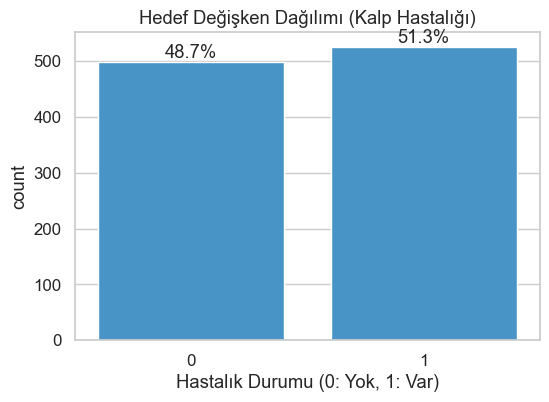

In [ ]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=target_col, data=df)

# Barların üzerine yüzde yazdırmak
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.title("Hedef Değişken Dağılımı (Kalp Hastalığı)")
plt.xlabel("Hastalık Durumu (0: Yok, 1: Var)")
plt.show()

### Bölüm 4: Sayısal Değişkenlerin Karşılaştırmalı Analizi
Burada sağlıklı ve hasta bireylerin sayısal değerlerinin (Yaş, Kolesterol vb.) 
nasıl ayrıştığını inceliyoruz. Histogramların üst üste binmemesi (separation), 
o değişkenin ayırt ediciliğini gösterir.

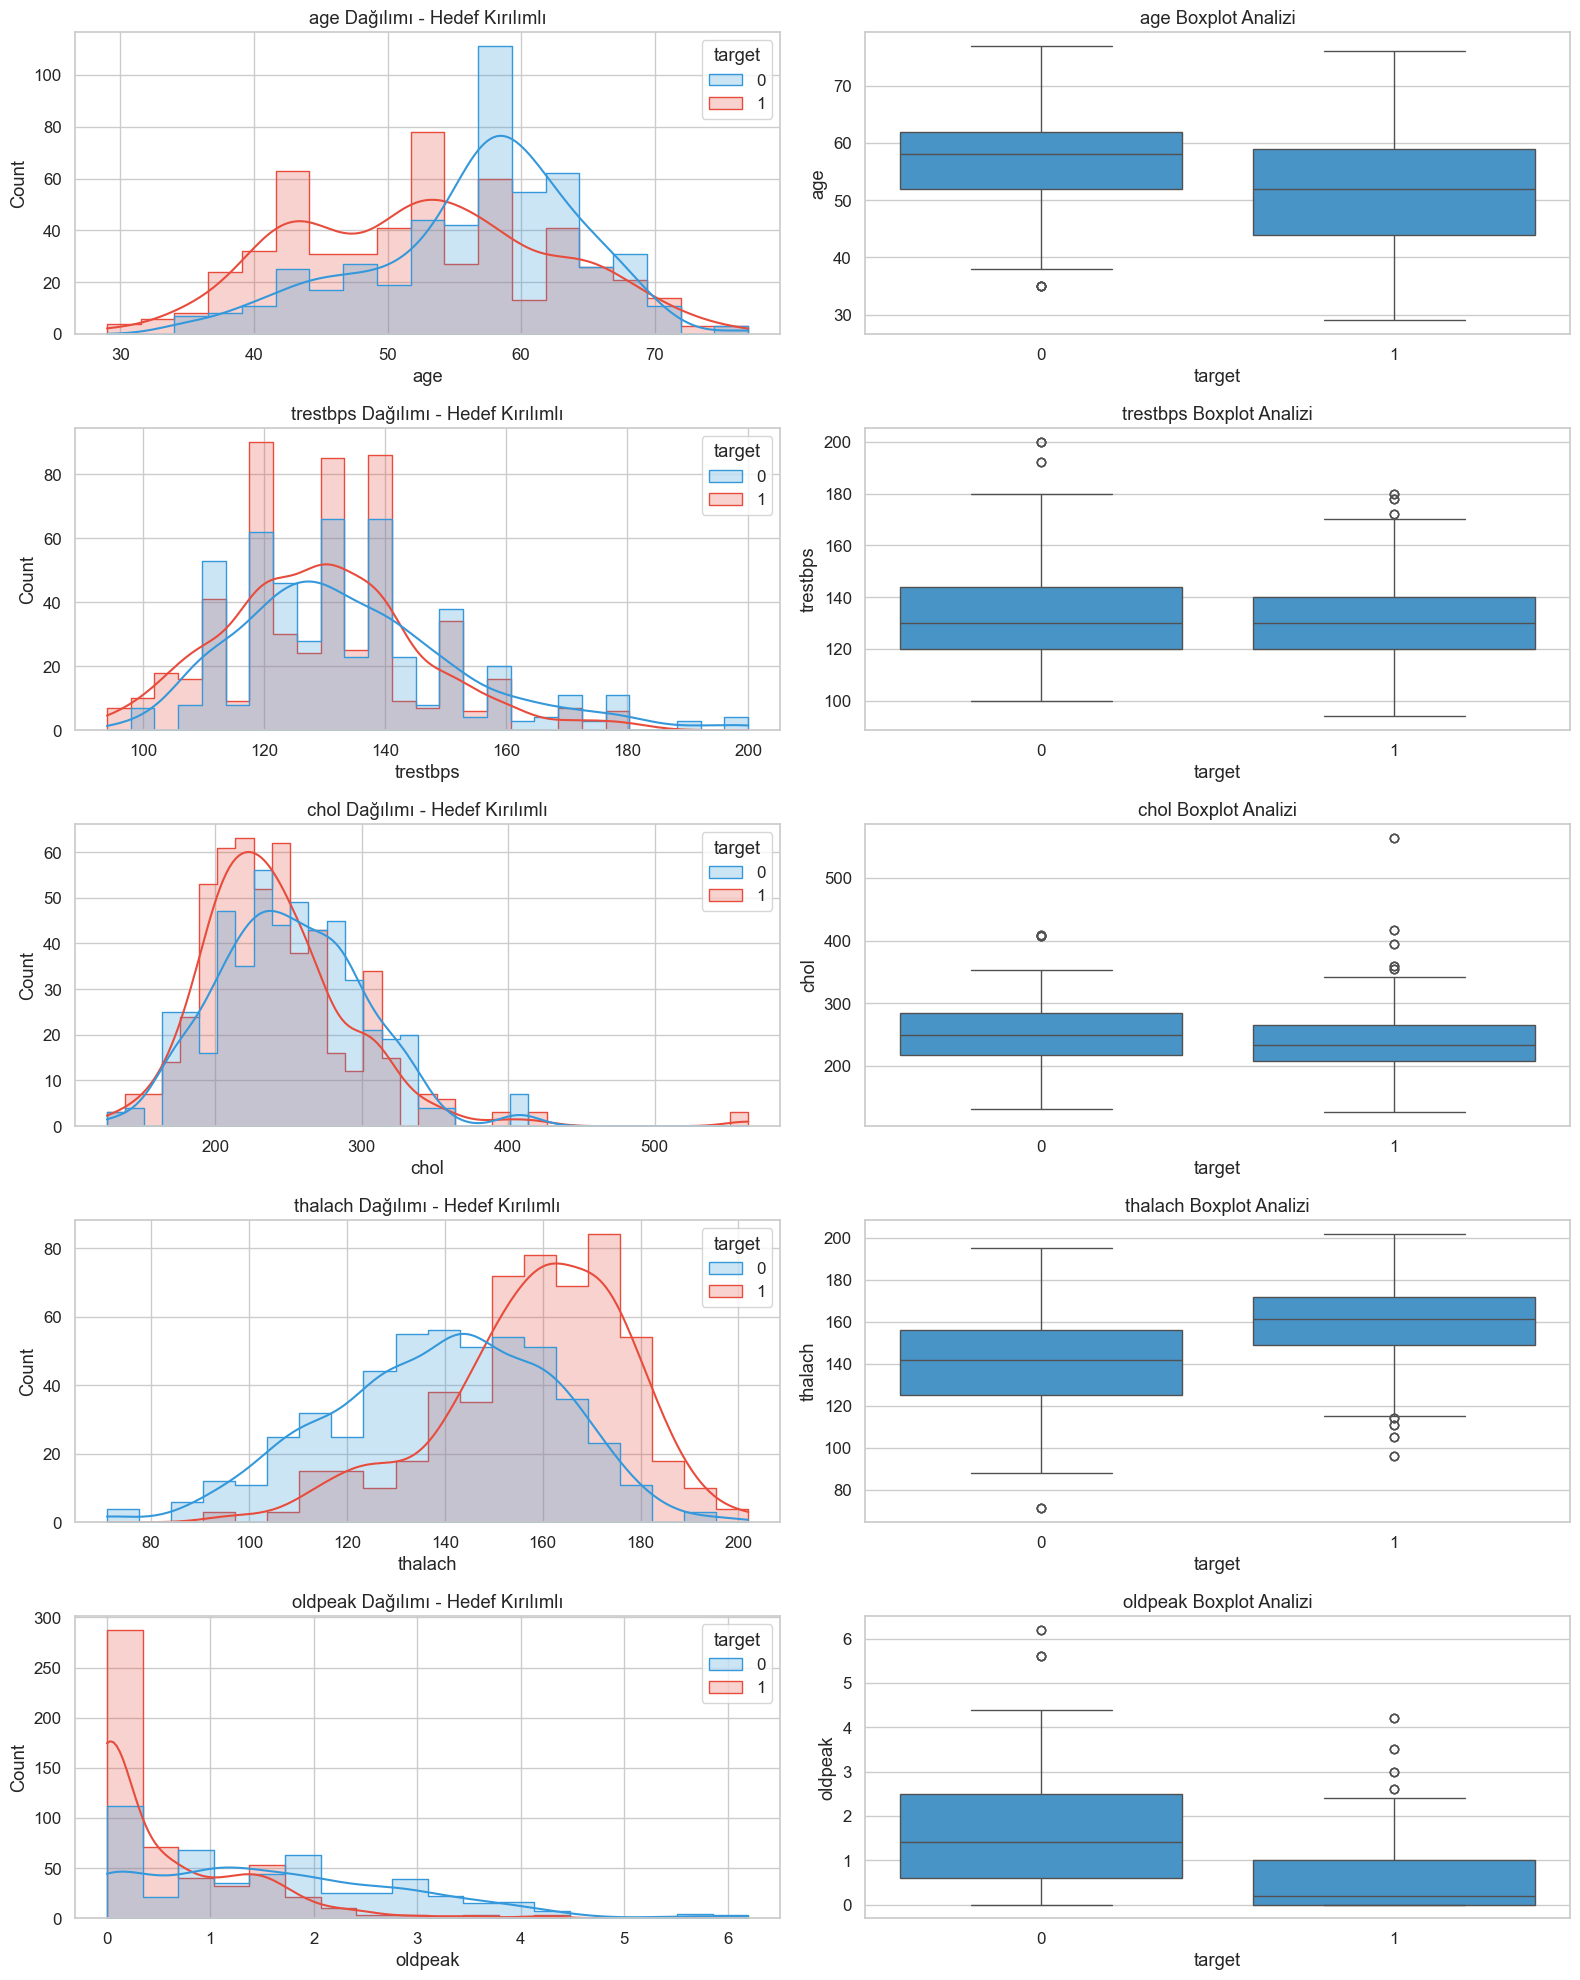

In [7]:
fig, axes = plt.subplots(len(numerical_cols), 2, figsize=(16, 20))

for i, col in enumerate(numerical_cols):
    # Sol taraf: Histogram (İç içe geçmiş dağılım)
    sns.histplot(data=df, x=col, hue=target_col, kde=True, element="step", ax=axes[i, 0])
    axes[i, 0].set_title(f'{col} Dağılımı - Hedef Kırılımlı')
    
    # Sağ taraf: Boxplot (Outlier ve Medyan farkı)
    sns.boxplot(data=df, x=target_col, y=col, ax=axes[i, 1])
    axes[i, 1].set_title(f'{col} Boxplot Analizi')

plt.tight_layout()
plt.show()

### Bölüm 5: Kategorik Değişkenler ve Risk Oranları
Her bir kategorinin kendi içindeki hastalık oranını inceliyoruz. 
Örneğin: Göğüs ağrısı tipi (cp) değiştikçe hastalık oranı dramatik şekilde artıyor mu?

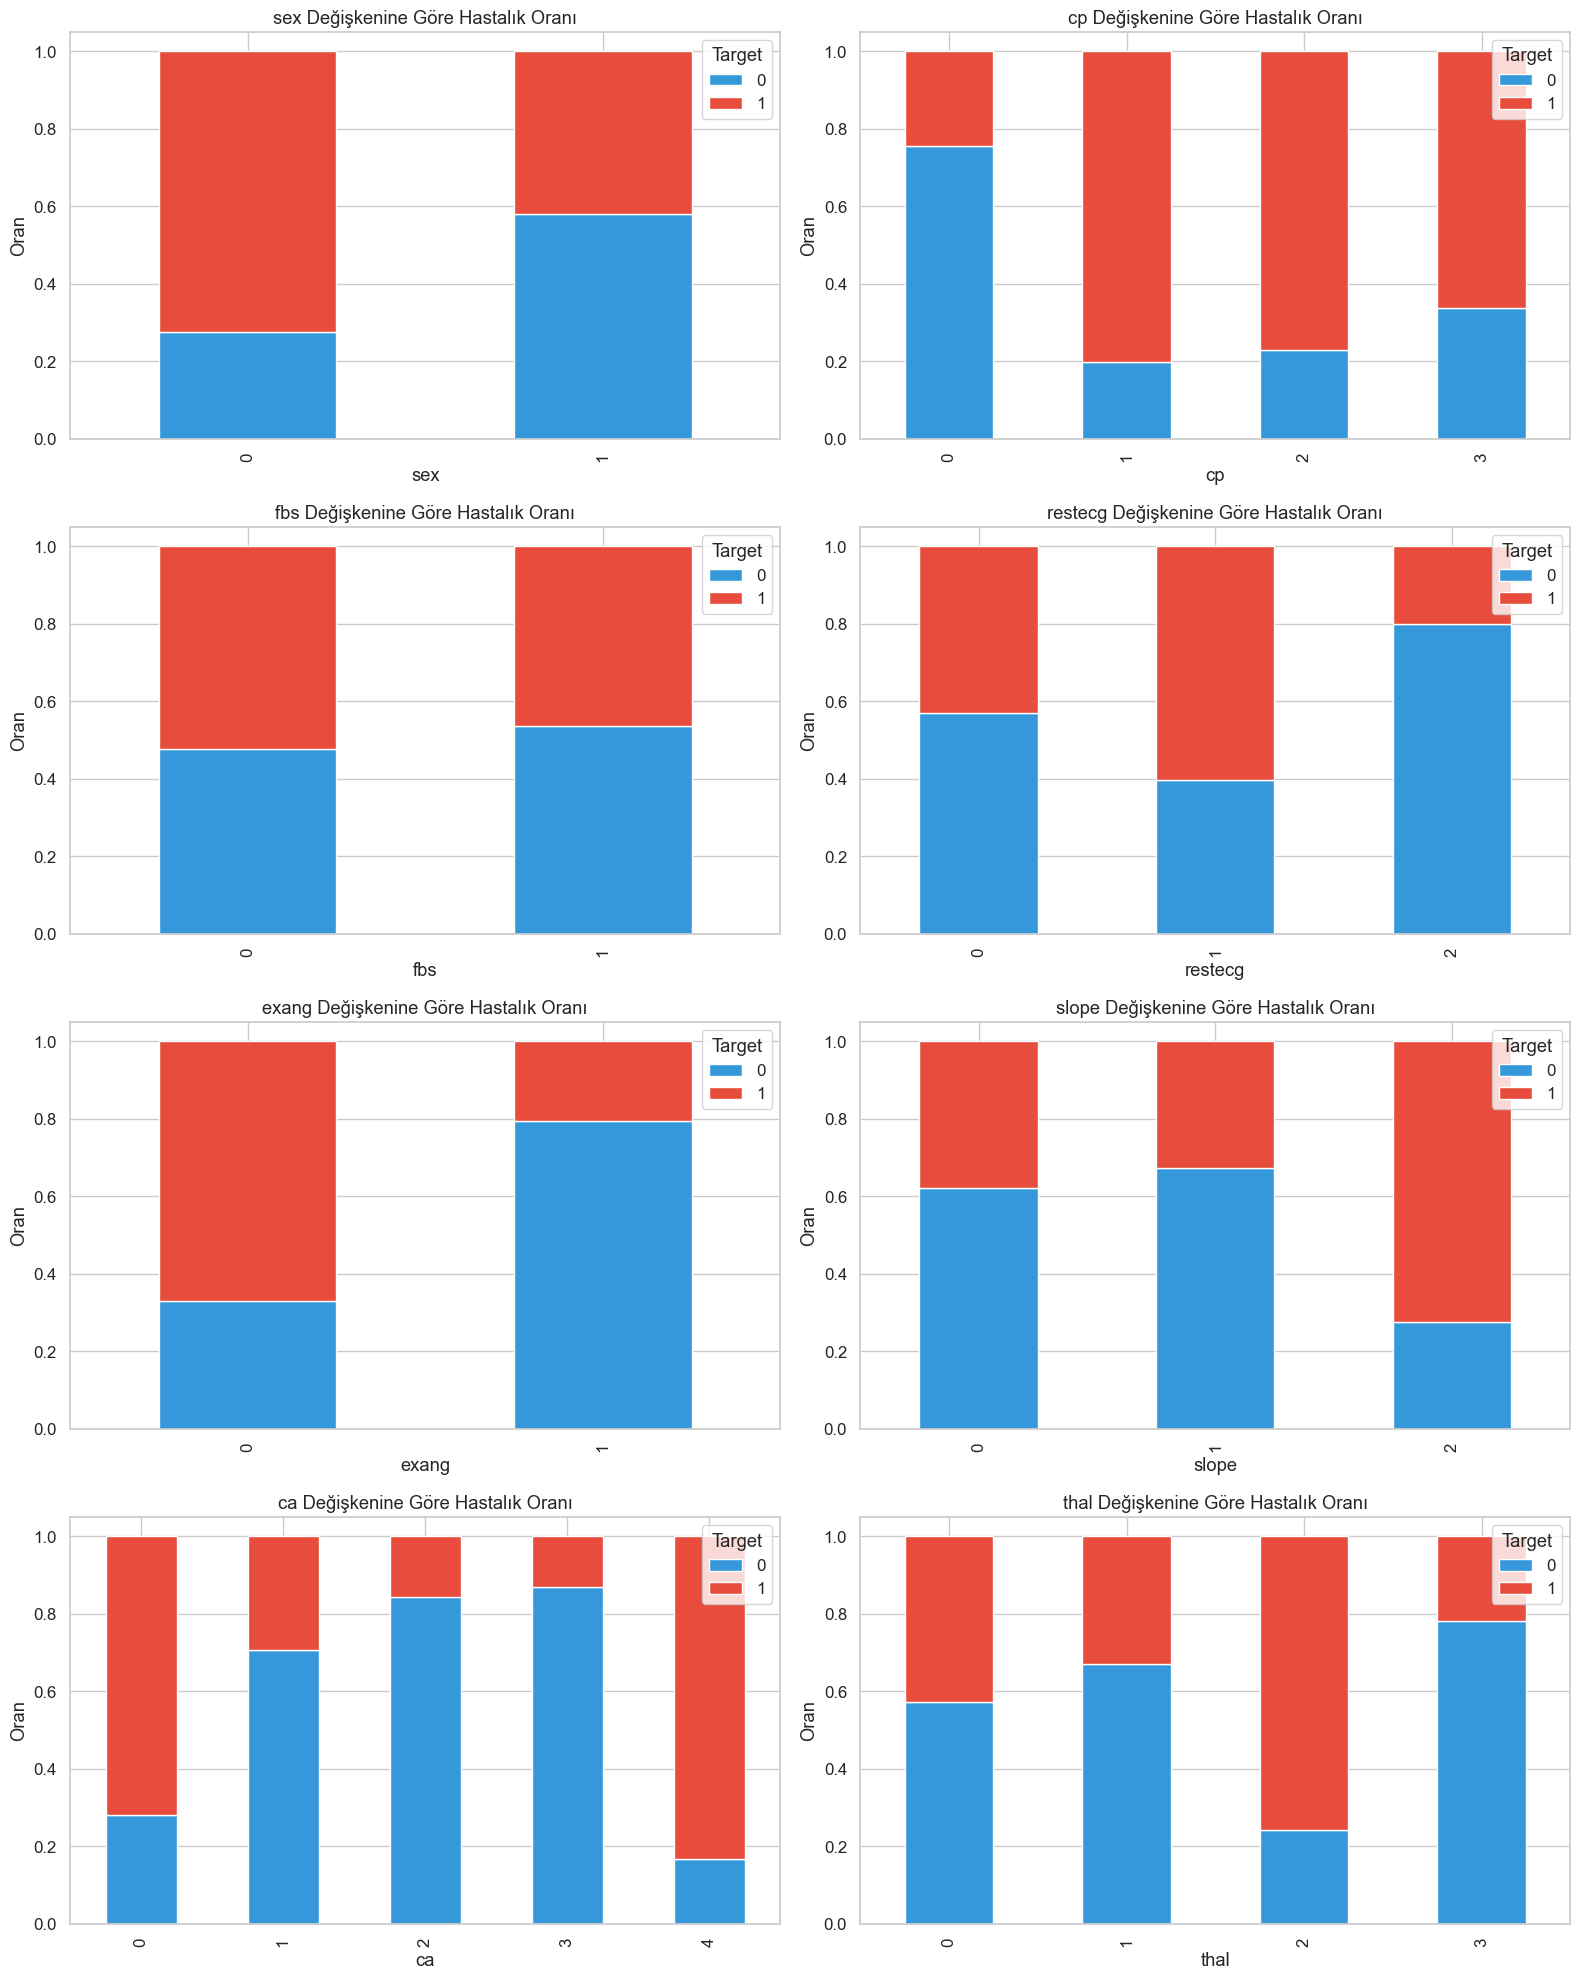

In [5]:
fig, axes = plt.subplots(4, 2, figsize=(16, 20)) # 8 kategorik değişken için 4x2 grid
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # Cross-tabulation ile oranları hesapla
    ct = pd.crosstab(df[col], df[target_col], normalize='index')
    
    # Stacked bar plot çiz
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=custom_palette)
    axes[i].set_title(f'{col} Değişkenine Göre Hastalık Oranı')
    axes[i].set_ylabel('Oran')
    axes[i].legend(title='Target', loc='upper right')

plt.tight_layout()
plt.show()

### Bölüm 6: Korelasyon ve Multicollinearity
Sadece sayısal değişkenler arasındaki ilişkiyi inceliyoruz. 
Not: Kategorik değişkenler için Chi-Square testi veya encoding sonrası korelasyon bakılmalıdır.

Text(0.5, 1.0, 'Sayısal Değişkenler Arası Korelasyon Matrisi')

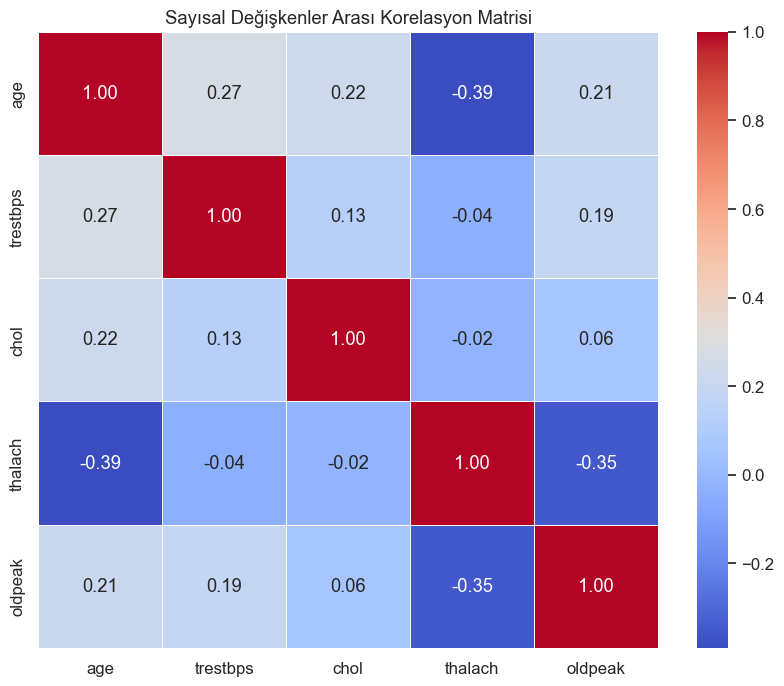

In [6]:
plt.figure(figsize=(10, 8))
# Sadece sayısal sütunları seçiyoruz
corr_matrix = df[numerical_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Sayısal Değişkenler Arası Korelasyon Matrisi")


# EDA Bulguları ve Analiz Raporu

## 1. Hedef Değişken Analizi (Target)

- **Denge Durumu:** Veri seti dengeliye yakın bir dağılım göstermektedir.
  - **Sağlıklı (0):** %48.7
  - **Kalp Hastalığı (1):** %51.3
- **Yorum:** Sınıf dengesizliği (imbalance) sorunu bulunmamaktadır. Veri seti dengeli olduğundan Accuracy metriği güvenilir bir başarım ölçütü olabilir; ancak tıbbi bağlam nedeniyle Recall ve ROC-AUC metrikleri kritik öneme sahiptir.

## 2. Kategorik Değişken Analizi (Risk Faktörleri)

Aşağıdaki değişkenlerin hastalıkla güçlü ilişkisi saptanmıştır:

- **Cinsiyet (Sex):**
  - Kadınların (0) yaklaşık **%75'inde** kalp hastalığı görülmüştür.
  - Erkeklerin (1) yaklaşık **%45'inde** kalp hastalığı görülmüştür.
  - **Yorum:** Cinsiyet önemli bir ayırt edicidir.
  - **Not:** Bu gözlem veri setine özgü olabilir ve klinik olarak genelleştirilmemelidir.

- **Göğüs Ağrısı (CP - Chest Pain):**
  - **Tip 0 (Typical Angina):** Bu gruptaki bireylerin **%73'ü sağlıklı**. Hastalıkla negatif ilişkilidir.
  - **Tip 1, 2, 3 (Atypical, Non-anginal):** Bu ağrı tiplerine sahip bireylerde hastalık oranı **%70-80** bandındadır. Yüksek risk göstergesidir.

- **Egzersize Bağlı Anjina (Exang):**
  - Egzersizle ağrısı **olmayanların (0)** %70'i hastadır (Bu veri setinde `target=1` hastalık ise).
  - Egzersizle ağrısı **olanların (1)** %77'si sağlıklıdır.
  - **Not:** Bu bulgu tıbbi beklentinin aksine olabilir (anjina genelde hastalık belirtisidir), ancak bu veri setinde (veya Kaggle versiyonunda) değişkenlerin kodlanması farklılık gösterebilir. Veri odaklı bakıldığında güçlü bir ayırıcıdır.

- **Thalassemia (Thal):**
  - Tip 2 (Sabit Defekt): %76 oranında hastalıkla ilişkili.
  - Tip 3 (Tersinir Defekt): %78 oranında sağlıkla ilişkili.
  - **Not:** Thal, güçlü non-linear davranışlar sergilediği için tree-based modeller için uygundur.

## 3. Sayısal Değişken Analizi

Grafiklerin ve istatistiklerin değerlendirilmesi:

- **Yaş (Age):**
  - Hasta bireylerin yaş ortalaması (52.4), sağlıklı bireylerden (56.6) daha düşüktür.
  - **Not:** Beklenenin aksine, bu veri setinde hastaların ortalama yaşı biraz daha düşük görünüyor. Bu durum veri setine özgü olabilir ve yaşın tek başına yeterli bir ayırıcı olmadığını düşündürmektedir.
- **Maksimum Kalp Hızı (Thalach):**
  - **Ayırt Edicilik:** Yüksek.
  - Hasta bireyler daha yüksek kalp atış hızlarına ulaşabilmektedir (Ort: 158 vs 139).
  - Boxplot ve histogramlarda belirgin bir ayrışma (separation) gözlenir.
  - **Not:** Bu beklenmedik sonuç, klinik varsayımlardan ziyade veriye dayalı modellemenin önemini vurgulamaktadır.
- **ST Depresyonu (Oldpeak):**
  - **Ayırt Edicilik:** Yüksek.
  - Hasta bireylerde ST depresyonu çok düşüktür (Ort: 0.6). Sağlıklı bireylerde daha yüksektir (Ort: 1.6).
  - **Not:** Bu veri setinde, daha yüksek oldpeak değerlerinin hastalıksız grupta daha sık gözlemlenmesi, veri setine özgü ters bir ilişkiye işaret etmektedir.
- **Kan Basıncı (Trestbps) ve Kolesterol (Chol):**
  - Bu iki değişkenin ortalamaları hasta ve sağlıklı gruplarda birbirine çok yakındır.
  - **Yorum:** Tek başlarına ayırt edici özellikleri düşüktür.

## 4. Genel Değerlendirme

- **En Güçlü Öznitelikler:** `cp` (göğüs ağrısı), `thalach` (kalp hızı), `exang` (egzersiz anjinası), `oldpeak` (ST depresyonu) ve `ca` (büyük damar sayısı).
- **Model Önerisi:** Ağaca dayalı modeller (Random Forest, XGBoost) bu kategorik ayrımları iyi yakalayacaktır. Değişkenler arası doğrusal olmayan ilişkiler (örn: yaş ve thalach) mevcuttur.

